In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

In [5]:
import os
import pandas as pd

# Project root = one level above notebooks/
PROJECT_DIR = os.path.dirname(os.getcwd())

RAW_DIR = os.path.join(
    PROJECT_DIR,
    "data",
    "raw"
)

print("Project directory:")
print(PROJECT_DIR)

print("\nRaw data directory:")
print(RAW_DIR)

Project directory:
c:\Users\rajpa\Downloads\OpsPulse Operational Intelligence

Raw data directory:
c:\Users\rajpa\Downloads\OpsPulse Operational Intelligence\data\raw


In [6]:
operations = pd.read_csv(
    os.path.join(RAW_DIR, "fact_operations.csv")
)

customers = pd.read_csv(
    os.path.join(RAW_DIR, "dim_customer.csv")
)

products = pd.read_csv(
    os.path.join(RAW_DIR, "dim_product.csv")
)

employees = pd.read_csv(
    os.path.join(RAW_DIR, "dim_employee.csv")
)

locations = pd.read_csv(
    os.path.join(RAW_DIR, "dim_location.csv")
)

dates = pd.read_csv(
    os.path.join(RAW_DIR, "dim_date.csv")
)

print("Operations:", operations.shape)
print("Customers:", customers.shape)
print("Products:", products.shape)
print("Employees:", employees.shape)
print("Locations:", locations.shape)
print("Dates:", dates.shape)

Operations: (150000, 19)
Customers: (5000, 3)
Products: (500, 3)
Employees: (500, 4)
Locations: (25, 4)
Dates: (2191, 10)


In [7]:
operations["order_date"] = pd.to_datetime(
    operations["order_date"]
)

operations["start_time"] = pd.to_datetime(
    operations["start_time"]
)

operations["completion_time"] = pd.to_datetime(
    operations["completion_time"]
)

operations["expected_completion"] = pd.to_datetime(
    operations["expected_completion"]
)

operations.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 19 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   operation_id           150000 non-null  object        
 1   order_id               150000 non-null  object        
 2   customer_id            150000 non-null  object        
 3   product_id             150000 non-null  object        
 4   employee_id            150000 non-null  object        
 5   location_id            150000 non-null  object        
 6   order_date             150000 non-null  datetime64[ns]
 7   start_time             150000 non-null  datetime64[ns]
 8   completion_time        150000 non-null  datetime64[ns]
 9   expected_completion    150000 non-null  datetime64[ns]
 10  status                 150000 non-null  object        
 11  quantity               150000 non-null  int64         
 12  processing_time_hours  150000 non-null  floa

In [8]:
total_operations = len(operations)

total_quantity = operations["quantity"].sum()

sla_compliance = (
    1 - operations["sla_breached"].mean()
) * 100

sla_breach_rate = (
    operations["sla_breached"].mean()
) * 100

avg_processing_time = (
    operations["processing_time_hours"].mean()
)

avg_delay = (
    operations["delay_minutes"].mean()
)

avg_quality = (
    operations["quality_score"].mean()
)

total_cost = (
    operations["cost"].sum()
)

cost_per_operation = (
    operations["cost"].mean()
)

cost_per_unit = (
    operations["cost"].sum()
    / operations["quantity"].sum()
)

avg_workload = (
    operations["workload"].mean()
)

kpis = pd.DataFrame({
    "Metric": [
        "Total Operations",
        "Total Quantity",
        "SLA Compliance %",
        "SLA Breach Rate %",
        "Avg Processing Time (hrs)",
        "Avg Delay (min)",
        "Avg Quality Score",
        "Total Cost",
        "Cost / Operation",
        "Cost / Unit",
        "Avg Workload"
    ],
    "Value": [
        total_operations,
        total_quantity,
        sla_compliance,
        sla_breach_rate,
        avg_processing_time,
        avg_delay,
        avg_quality,
        total_cost,
        cost_per_operation,
        cost_per_unit,
        avg_workload
    ]
})

kpis

,Metric,Value
0,Total Operations,"150,000.00"
1,Total Quantity,"1,179,390.00"
2,SLA Compliance %,78.16
3,SLA Breach Rate %,21.84
4,Avg Processing Time (hrs),4.54
5,Avg Delay (min),17.61
6,Avg Quality Score,90.07
7,Total Cost,"36,891,393.44"
8,Cost / Operation,245.94
9,Cost / Unit,31.28


In [9]:
monthly = (
    operations
    .groupby(
        operations["order_date"].dt.to_period("M")
    )
    .agg(
        operations=("operation_id", "count"),
        quantity=("quantity", "sum"),
        sla_compliance=(
            "sla_breached",
            lambda x: (1 - x.mean()) * 100
        ),
        avg_processing_time=(
            "processing_time_hours",
            "mean"
        ),
        avg_delay=(
            "delay_minutes",
            "mean"
        ),
        total_cost=(
            "cost",
            "sum"
        )
    )
    .reset_index()
)

monthly["order_date"] = (
    monthly["order_date"]
    .dt.to_timestamp()
)

monthly.head()

,order_date,operations,quantity,sla_compliance,avg_processing_time,avg_delay,total_cost
0,2021-01-01,2148,15685,81.66,4.16,16.82,"500,835.60"
1,2021-02-01,1782,13034,79.63,4.27,18.17,"422,281.33"
2,2021-03-01,2109,15611,81.60,4.23,15.78,"494,750.29"
3,2021-04-01,2092,15363,81.36,4.19,15.20,"486,721.48"
4,2021-05-01,2105,15024,84.13,3.99,14.25,"476,158.29"


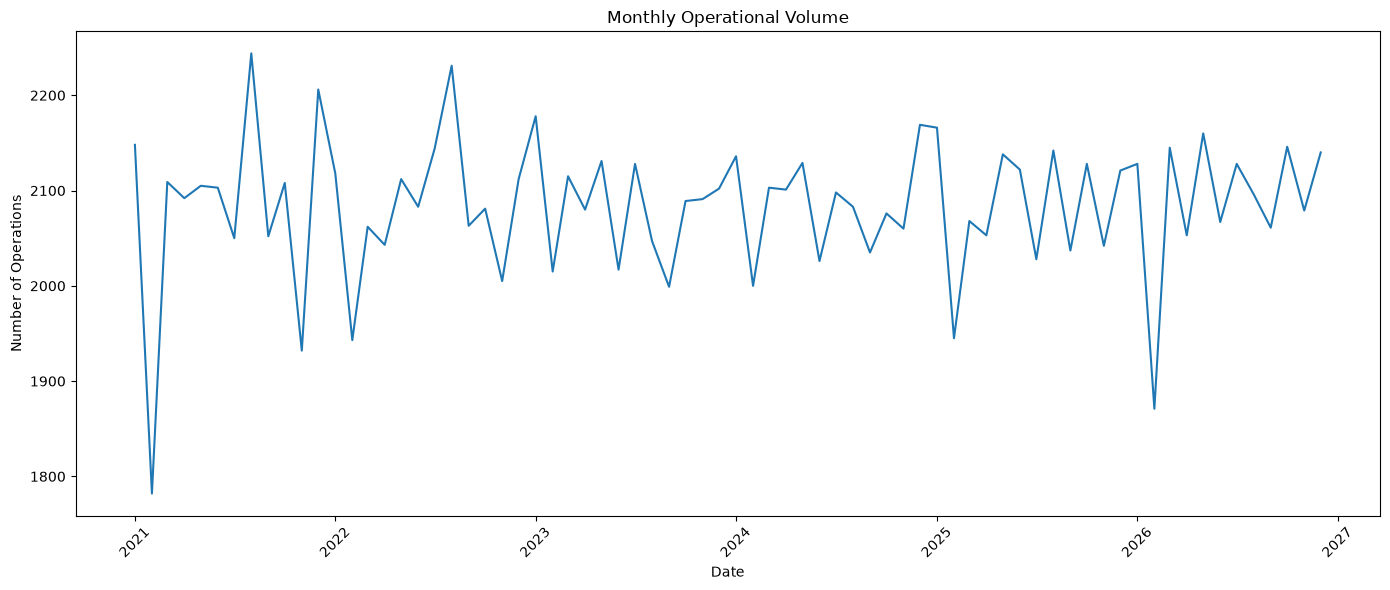

In [10]:
plt.figure(figsize=(14, 6))

plt.plot(
    monthly["order_date"],
    monthly["operations"]
)

plt.title("Monthly Operational Volume")
plt.xlabel("Date")
plt.ylabel("Number of Operations")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

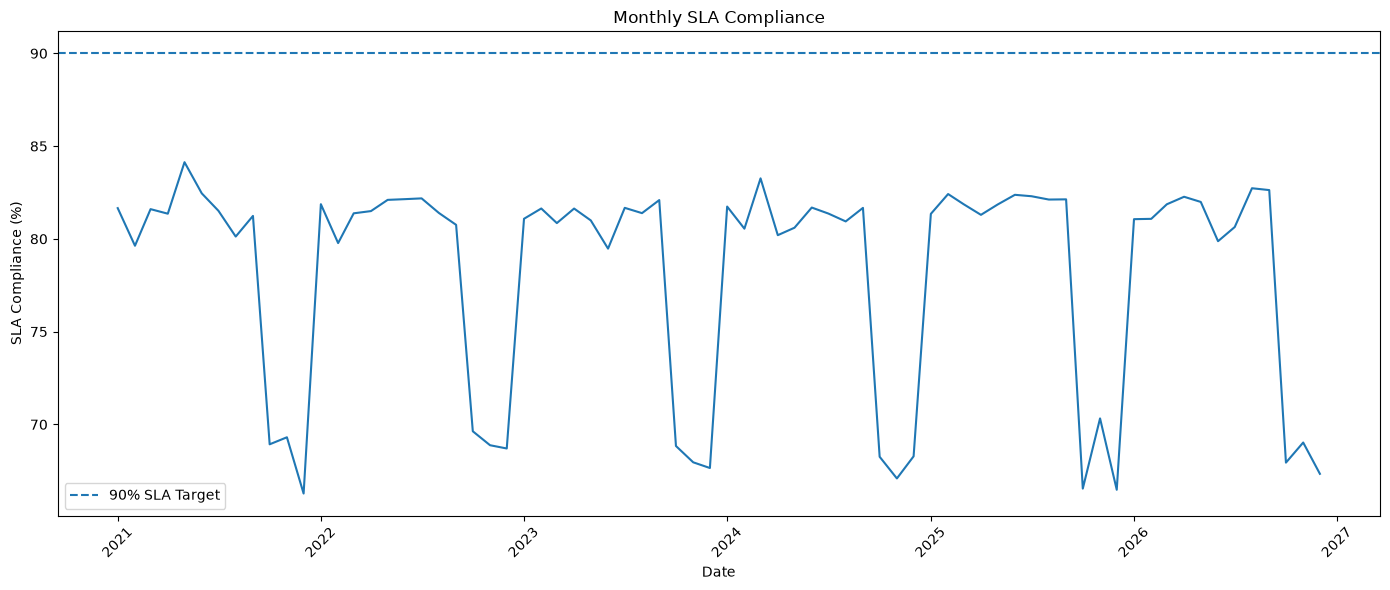

In [11]:
plt.figure(figsize=(14, 6))

plt.plot(
    monthly["order_date"],
    monthly["sla_compliance"]
)

plt.axhline(
    90,
    linestyle="--",
    label="90% SLA Target"
)

plt.title("Monthly SLA Compliance")
plt.xlabel("Date")
plt.ylabel("SLA Compliance (%)")

plt.legend()

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

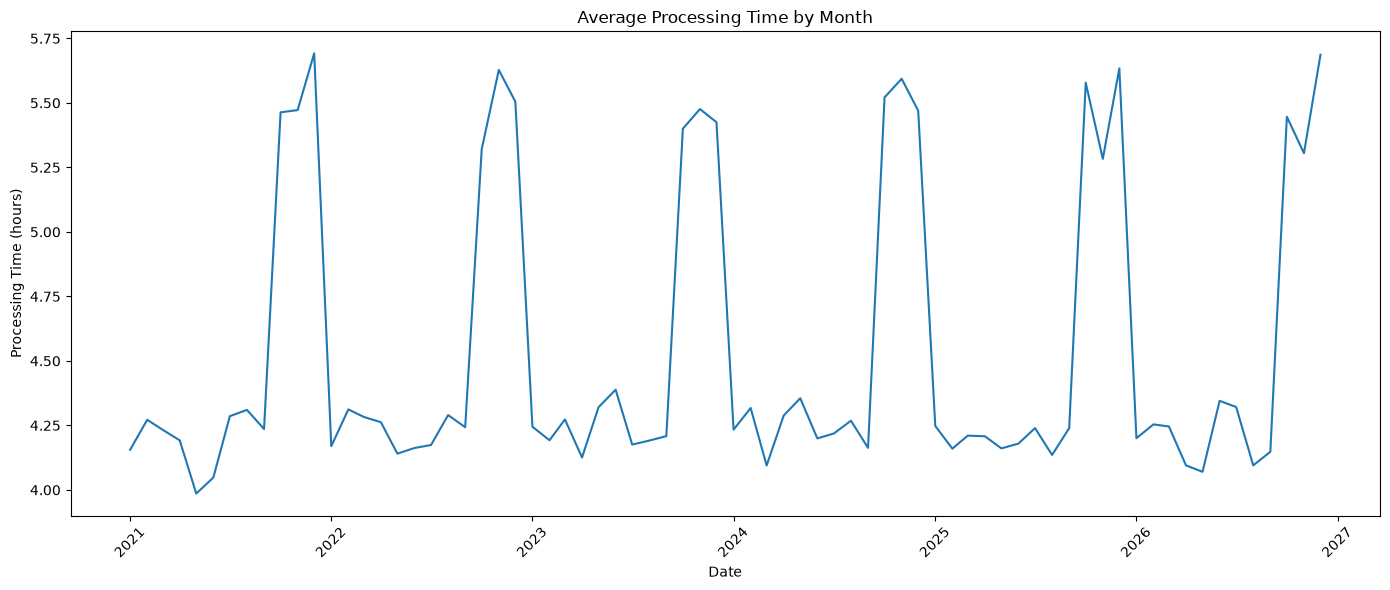

In [12]:
plt.figure(figsize=(14, 6))

plt.plot(
    monthly["order_date"],
    monthly["avg_processing_time"]
)

plt.title("Average Processing Time by Month")
plt.xlabel("Date")
plt.ylabel("Processing Time (hours)")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [13]:
correlation = monthly[
    [
        "operations",
        "quantity",
        "sla_compliance",
        "avg_processing_time",
        "avg_delay"
    ]
].corr()

correlation

,operations,quantity,sla_compliance,avg_processing_time,avg_delay
operations,1.00,0.36,-0.08,0.08,0.04
quantity,0.36,1.00,-0.95,0.95,0.85
sla_compliance,-0.08,-0.95,1.00,-0.99,-0.92
avg_processing_time,0.08,0.95,-0.99,1.00,0.92
avg_delay,0.04,0.85,-0.92,0.92,1.00


In [14]:
operations_employee = operations.merge(
    employees,
    on="employee_id",
    how="left"
)

operations_employee.head()

,operation_id,order_id,customer_id,product_id,employee_id,location_id,order_date,start_time,completion_time,expected_completion,status,quantity,processing_time_hours,delay_minutes,sla_target_hours,sla_breached,workload,cost,quality_score,department,team,experience_level
0,OP_0000001,ORD_0000001,CUST_00603,PROD_0257,EMP_0346,LOC_019,2026-09-01,2026-09-01 07:30:00,2026-09-01 09:11:28.337181295,2026-09-01 13:30:00,Completed,7,1.69,0.00,6,False,5.67,148.48,93.94,Dispatch,Team A,Senior
1,OP_0000002,ORD_0000002,CUST_01508,PROD_0257,EMP_0300,LOC_021,2022-09-09,2022-09-09 16:26:00,2022-09-09 22:16:13.214173833,2022-09-09 22:26:00,Completed,9,5.84,0.00,6,False,12.09,263.39,83.64,Processing,Team C,Senior
2,OP_0000003,ORD_0000003,CUST_03896,PROD_0208,EMP_0127,LOC_022,2021-05-29,2021-05-29 07:15:00,2021-05-29 08:45:29.070202838,2021-05-29 13:15:00,Completed,5,1.51,0.00,6,False,5.74,130.90,93.83,Processing,Team D,Junior
3,OP_0000004,ORD_0000004,CUST_04125,PROD_0308,EMP_0411,LOC_010,2025-12-17,2025-12-17 07:23:00,2025-12-17 20:16:08.206603746,2025-12-17 13:23:00,Delayed,7,6.17,402.81,6,True,6.49,582.14,83.07,Processing,Team E,Junior
4,OP_0000005,ORD_0000005,CUST_04363,PROD_0104,EMP_0385,LOC_023,2021-06-21,2021-06-21 15:57:00,2021-06-21 20:56:41.628112447,2021-06-21 21:57:00,Completed,8,4.99,0.00,6,False,7.11,247.34,91.40,Dispatch,Team A,Mid


In [15]:
department_performance = (
    operations_employee
    .groupby("department")
    .agg(
        operations=("operation_id", "count"),
        avg_processing_time=(
            "processing_time_hours",
            "mean"
        ),
        avg_delay=(
            "delay_minutes",
            "mean"
        ),
        sla_compliance=(
            "sla_breached",
            lambda x: (1 - x.mean()) * 100
        ),
        avg_quality=(
            "quality_score",
            "mean"
        ),
        avg_workload=(
            "workload",
            "mean"
        ),
        total_cost=(
            "cost",
            "sum"
        )
    )
    .reset_index()
)

department_performance

,department,operations,avg_processing_time,avg_delay,sla_compliance,avg_quality,avg_workload,total_cost
0,Dispatch,29672,3.75,12.03,83.24,91.19,8.66,"6,591,032.71"
1,Packaging,32220,3.72,11.63,83.71,91.17,8.66,"7,125,182.17"
2,Processing,53856,3.67,11.17,84.29,91.27,8.64,"11,814,362.71"
3,Quality,34252,7.35,38.22,58.91,86.14,8.64,"11,360,815.85"


In [16]:
experience_performance = (
    operations_employee
    .groupby("experience_level")
    .agg(
        operations=("operation_id", "count"),
        avg_processing_time=(
            "processing_time_hours",
            "mean"
        ),
        sla_compliance=(
            "sla_breached",
            lambda x: (1 - x.mean()) * 100
        ),
        avg_quality=(
            "quality_score",
            "mean"
        ),
        avg_workload=(
            "workload",
            "mean"
        )
    )
    .reset_index()
)

experience_performance

,experience_level,operations,avg_processing_time,sla_compliance,avg_quality,avg_workload
0,Junior,48966,5.40,69.30,88.94,8.63
1,Mid,70772,4.30,80.57,90.40,8.66
2,Senior,30262,3.69,86.88,91.11,8.67


In [17]:
operations["workload_band"] = pd.cut(
    operations["workload"],
    bins=[
        0,
        5,
        10,
        15,
        20,
        np.inf
    ],
    labels=[
        "Low",
        "Moderate",
        "High",
        "Very High",
        "Extreme"
    ]
)

In [18]:
workload_performance = (
    operations
    .groupby(
        "workload_band",
        observed=True
    )
    .agg(
        operations=("operation_id", "count"),
        avg_processing_time=(
            "processing_time_hours",
            "mean"
        ),
        avg_delay=(
            "delay_minutes",
            "mean"
        ),
        sla_compliance=(
            "sla_breached",
            lambda x: (1 - x.mean()) * 100
        ),
        avg_quality=(
            "quality_score",
            "mean"
        )
    )
    .reset_index()
)

workload_performance

,workload_band,operations,avg_processing_time,avg_delay,sla_compliance,avg_quality
0,Low,24413,3.98,14.19,83.94,90.81
1,Moderate,77367,4.44,15.99,79.34,90.22
2,High,38946,4.89,17.59,74.85,89.65
3,Very High,8188,5.23,40.42,67.43,88.63
4,Extreme,1086,5.48,39.27,64.36,88.19


In [31]:
# ============================================================
# REBUILD STAGE SUMMARY CLEANLY
# ============================================================

stage_data = operations_employee.copy()

stage_data["processing_stage_hours"] = (
    stage_data["processing_time_hours"] * 0.45
)

stage_data["quality_stage_hours"] = (
    stage_data["processing_time_hours"] * 0.30
)

stage_data["packaging_stage_hours"] = (
    stage_data["processing_time_hours"] * 0.15
)

stage_data["dispatch_stage_hours"] = (
    stage_data["processing_time_hours"] * 0.10
)

stage_summary = pd.DataFrame({
    "stage": [
        "Processing",
        "Quality Check",
        "Packaging",
        "Dispatch"
    ],

    "avg_time_hours": [
        stage_data["processing_stage_hours"].mean(),
        stage_data["quality_stage_hours"].mean(),
        stage_data["packaging_stage_hours"].mean(),
        stage_data["dispatch_stage_hours"].mean()
    ],

    "total_time_hours": [
        stage_data["processing_stage_hours"].sum(),
        stage_data["quality_stage_hours"].sum(),
        stage_data["packaging_stage_hours"].sum(),
        stage_data["dispatch_stage_hours"].sum()
    ]
})

stage_summary["percentage_of_total"] = (
    stage_summary["total_time_hours"]
    / stage_summary["total_time_hours"].sum()
    * 100
)

stage_summary

,stage,avg_time_hours,total_time_hours,percentage_of_total
0,Processing,2.04,"306,175.87",45.00
1,Quality Check,1.36,"204,117.25",30.00
2,Packaging,0.68,"102,058.62",15.00
3,Dispatch,0.45,"68,039.08",10.00


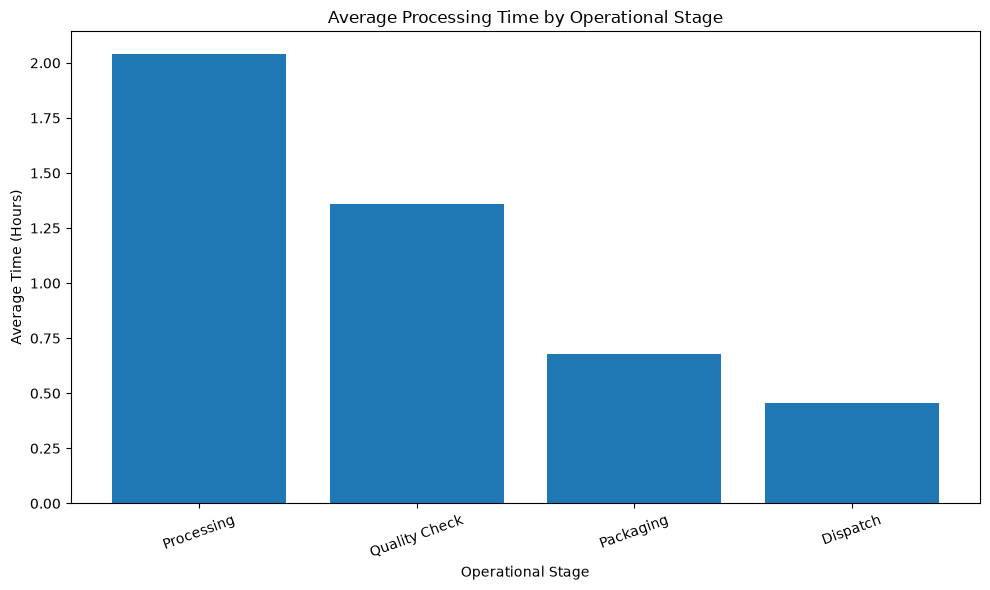

In [32]:
plt.figure(figsize=(10, 6))

plt.bar(
    stage_summary["stage"],
    stage_summary["avg_time_hours"]
)

plt.title("Average Processing Time by Operational Stage")
plt.xlabel("Operational Stage")
plt.ylabel("Average Time (Hours)")

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

In [33]:
primary_bottleneck = stage_summary.loc[
    stage_summary["avg_time_hours"].idxmax()
]

primary_bottleneck

stage                  Processing
avg_time_hours               2.04
total_time_hours       306,175.87
percentage_of_total         45.00
Name: 0, dtype: object

In [34]:
print(
    f"Primary bottleneck: "
    f"{primary_bottleneck['stage']}"
)

print(
    f"Average time: "
    f"{primary_bottleneck['avg_time_hours']:.2f} hours"
)

print(
    f"Share of process time: "
    f"{primary_bottleneck['percentage_of_total']:.2f}%"
)

Primary bottleneck: Processing
Average time: 2.04 hours
Share of process time: 45.00%


In [37]:
# ============================================================
# STAGE TARGETS
# ============================================================

stage_targets = pd.DataFrame({
    "stage": [
        "Processing",
        "Quality Check",
        "Packaging",
        "Dispatch"
    ],

    "target_time_hours": [
        2.0,
        3.0,
        1.5,
        2.0
    ]
})

stage_summary = stage_summary.merge(
    stage_targets,
    on="stage",
    how="left"
)

stage_summary["variance_hours"] = (
    stage_summary["avg_time_hours"]
    - stage_summary["target_time_hours"]
)

stage_summary["variance_pct"] = (
    stage_summary["variance_hours"]
    / stage_summary["target_time_hours"]
    * 100
)

stage_summary

,stage,avg_time_hours,total_time_hours,percentage_of_total,target_hours_x,variance_hours,variance_pct,target_hours_y,target_time_hours
0,Processing,2.04,"306,175.87",45.00,2.00,0.04,2.06,2.00,2.00
1,Quality Check,1.36,"204,117.25",30.00,3.00,-1.64,-54.64,3.00,3.00
2,Packaging,0.68,"102,058.62",15.00,1.50,-0.82,-54.64,1.50,1.50
3,Dispatch,0.45,"68,039.08",10.00,2.00,-1.55,-77.32,2.00,2.00


In [38]:
bottleneck_ranking = (
    stage_summary
    .sort_values(
        "variance_pct",
        ascending=False
    )
    .reset_index(drop=True)
)

bottleneck_ranking[
    [
        "stage",
        "avg_time_hours",
        "target_time_hours",
        "variance_hours",
        "variance_pct"
    ]
]

,stage,avg_time_hours,target_time_hours,variance_hours,variance_pct
0,Processing,2.04,2.00,0.04,2.06
1,Quality Check,1.36,3.00,-1.64,-54.64
2,Packaging,0.68,1.50,-0.82,-54.64
3,Dispatch,0.45,2.00,-1.55,-77.32


In [39]:
stage_path = os.path.join(
    RAW_DIR,
    "fact_operation_stages.csv"
)

stages = pd.read_csv(
    stage_path,
    parse_dates=[
        "stage_start_time",
        "stage_end_time"
    ]
)

print("Stage data shape:", stages.shape)

stages.head()

Stage data shape: (600000, 10)


,operation_id,stage_id,stage_name,stage_sequence,stage_start_time,stage_end_time,stage_duration_minutes,target_time_minutes,stage_variance_minutes,stage_status
0,OP_0000001,STG_01,Processing,1,2026-09-01 07:30:00.000000000,2026-09-01 08:00:39.874316004,30.66,90,-59.34,Within Target
1,OP_0000001,STG_02,Quality Check,2,2026-09-01 08:00:39.874316004,2026-09-01 08:39:33.186130638,38.89,75,-36.11,Within Target
2,OP_0000001,STG_03,Packaging,3,2026-09-01 08:39:33.186130638,2026-09-01 08:58:09.934295040,18.61,45,-26.39,Within Target
3,OP_0000001,STG_04,Dispatch,4,2026-09-01 08:58:09.934295040,2026-09-01 09:11:24.000000006,13.23,40,-26.77,Within Target
4,OP_0000002,STG_01,Processing,1,2022-09-09 16:26:00.000000000,2022-09-09 18:05:25.325299980,99.42,90,9.42,Delayed


In [40]:
stage_performance = (
    stages
    .groupby("stage_name")
    .agg(
        operations=("operation_id", "nunique"),
        avg_duration_minutes=(
            "stage_duration_minutes",
            "mean"
        ),
        median_duration_minutes=(
            "stage_duration_minutes",
            "median"
        ),
        target_time_minutes=(
            "target_time_minutes",
            "mean"
        ),
        avg_variance_minutes=(
            "stage_variance_minutes",
            "mean"
        ),
        delayed_operations=(
            "stage_status",
            lambda x: (x == "Delayed").sum()
        )
    )
    .reset_index()
)

stage_performance["delay_rate_pct"] = (
    stage_performance["delayed_operations"]
    / stage_performance["operations"]
    * 100
)

stage_performance["variance_pct"] = (
    stage_performance["avg_variance_minutes"]
    / stage_performance["target_time_minutes"]
    * 100
)

stage_performance.sort_values(
    "variance_pct",
    ascending=False
)

,stage_name,operations,avg_duration_minutes,median_duration_minutes,target_time_minutes,avg_variance_minutes,delayed_operations,delay_rate_pct,variance_pct
3,Quality Check,150000,110.47,88.29,75.00,35.47,88495,59.00,47.29
1,Packaging,150000,48.54,38.83,45.00,3.54,62662,41.77,7.86
2,Processing,150000,80.79,64.69,90.00,-9.21,47821,31.88,-10.23
0,Dispatch,150000,32.36,25.90,40.00,-7.64,39970,26.65,-19.10


In [41]:
primary_bottleneck = (
    stage_performance
    .sort_values(
        "variance_pct",
        ascending=False
    )
    .iloc[0]
)

print(
    "Primary bottleneck:",
    primary_bottleneck["stage_name"]
)

print(
    f"Average duration: "
    f"{primary_bottleneck['avg_duration_minutes']:.2f} minutes"
)

print(
    f"Target duration: "
    f"{primary_bottleneck['target_time_minutes']:.2f} minutes"
)

print(
    f"Variance: "
    f"{primary_bottleneck['variance_pct']:.2f}%"
)

print(
    f"Delay rate: "
    f"{primary_bottleneck['delay_rate_pct']:.2f}%"
)

Primary bottleneck: Quality Check
Average duration: 110.47 minutes
Target duration: 75.00 minutes
Variance: 47.29%
Delay rate: 59.00%


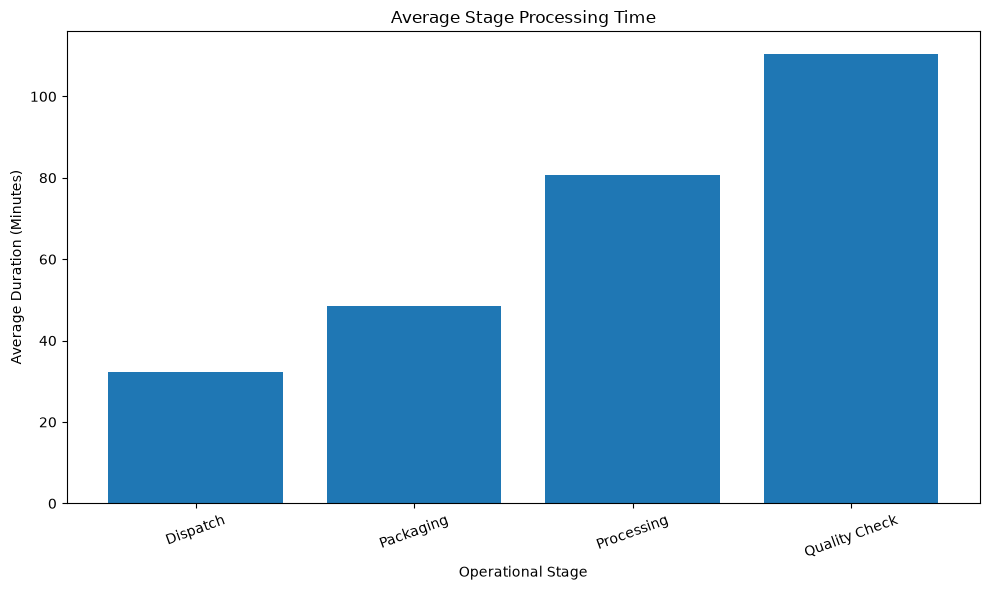

In [42]:
plt.figure(figsize=(10, 6))

plt.bar(
    stage_performance["stage_name"],
    stage_performance["avg_duration_minutes"]
)

plt.title(
    "Average Stage Processing Time"
)

plt.xlabel("Operational Stage")

plt.ylabel(
    "Average Duration (Minutes)"
)

plt.xticks(rotation=20)

plt.tight_layout()

plt.show()

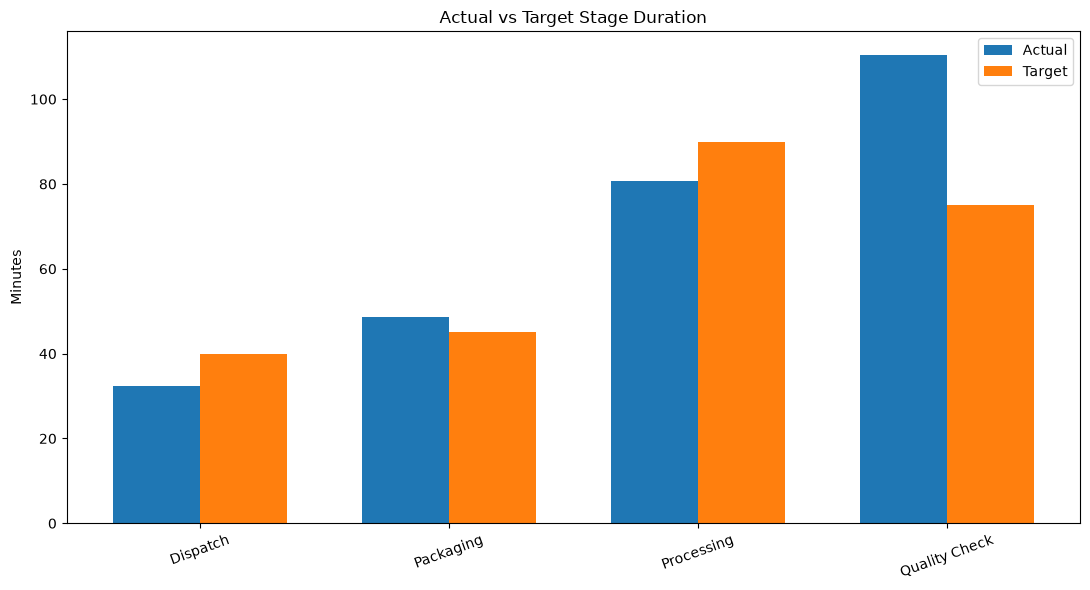

In [43]:
x = np.arange(
    len(stage_performance)
)

width = 0.35

plt.figure(figsize=(11, 6))

plt.bar(
    x - width / 2,
    stage_performance[
        "avg_duration_minutes"
    ],
    width,
    label="Actual"
)

plt.bar(
    x + width / 2,
    stage_performance[
        "target_time_minutes"
    ],
    width,
    label="Target"
)

plt.xticks(
    x,
    stage_performance["stage_name"],
    rotation=20
)

plt.ylabel("Minutes")

plt.title(
    "Actual vs Target Stage Duration"
)

plt.legend()

plt.tight_layout()

plt.show()

In [44]:
stages["workload_band"] = pd.cut(
    operations.set_index(
        "operation_id"
    )["workload"]
    .reindex(
        stages["operation_id"]
    )
    .values,

    bins=[
        0,
        5,
        10,
        15,
        20,
        np.inf
    ],

    labels=[
        "Low",
        "Moderate",
        "High",
        "Very High",
        "Extreme"
    ]
)

In [45]:
stage_workload = (
    stages
    .groupby(
        [
            "stage_name",
            "workload_band"
        ],
        observed=True
    )
    .agg(
        operations=("operation_id", "nunique"),
        avg_duration_minutes=(
            "stage_duration_minutes",
            "mean"
        ),
        avg_variance_minutes=(
            "stage_variance_minutes",
            "mean"
        ),
        delay_rate_pct=(
            "stage_status",
            lambda x:
            (x == "Delayed").mean() * 100
        )
    )
    .reset_index()
)

stage_workload

,stage_name,workload_band,operations,avg_duration_minutes,avg_variance_minutes,delay_rate_pct
0,Dispatch,Low,24413,28.72,-11.28,21.12
1,Dispatch,Moderate,77367,32.03,-7.97,26.31
2,Dispatch,High,38946,34.59,-5.41,29.89
3,Dispatch,Very High,8188,35.31,-4.69,30.41
4,Dispatch,Extreme,1086,35.27,-4.73,30.29
5,Packaging,Low,24413,43.05,-1.95,35.42
6,Packaging,Moderate,77367,48.07,3.07,41.29
7,Packaging,High,38946,51.85,6.85,45.65
8,Packaging,Very High,8188,52.96,7.96,46.29
9,Packaging,Extreme,1086,52.78,7.78,45.95


In [46]:
bottleneck_workload = stage_workload[
    stage_workload["stage_name"]
    == primary_bottleneck["stage_name"]
].copy()

bottleneck_workload

,stage_name,workload_band,operations,avg_duration_minutes,avg_variance_minutes,delay_rate_pct
15,Quality Check,Low,24413,95.45,20.45,51.61
16,Quality Check,Moderate,77367,106.54,31.54,57.37
17,Quality Check,High,38946,120.88,45.88,63.97
18,Quality Check,Very High,8188,137.27,62.27,70.47
19,Quality Check,Extreme,1086,152.78,77.78,76.24


In [47]:
workload_numeric = (
    stages["workload_band"]
    .map({
        "Low": 1,
        "Moderate": 2,
        "High": 3,
        "Very High": 4,
        "Extreme": 5
    })
)

correlation = pd.DataFrame({
    "workload_level": workload_numeric,
    "stage_duration": stages[
        "stage_duration_minutes"
    ]
}).corr()

correlation

,workload_level,stage_duration
workload_level,1.00,0.08
stage_duration,0.08,1.00


In [49]:
PROCESSED_DIR = os.path.join(
    PROJECT_DIR,
    "data",
    "processed"
)

os.makedirs(
    PROCESSED_DIR,
    exist_ok=True
)

print("Processed directory:")
print(PROCESSED_DIR)

Processed directory:
c:\Users\rajpa\Downloads\OpsPulse Operational Intelligence\data\processed


In [50]:
stage_performance.to_csv(
    os.path.join(
        PROCESSED_DIR,
        "stage_performance.csv"
    ),
    index=False
)

stage_workload.to_csv(
    os.path.join(
        PROCESSED_DIR,
        "stage_workload_analysis.csv"
    ),
    index=False
)

bottleneck_workload.to_csv(
    os.path.join(
        PROCESSED_DIR,
        "bottleneck_workload_analysis.csv"
    ),
    index=False
)

print(
    "Bottleneck analysis saved successfully."
)

Bottleneck analysis saved successfully.


In [51]:
operation_workload = operations[
    [
        "operation_id",
        "workload"
    ]
].drop_duplicates()

stages_analysis = stages.merge(
    operation_workload,
    on="operation_id",
    how="left"
)

print("Stage analysis shape:", stages_analysis.shape)

Stage analysis shape: (600000, 12)


In [52]:
stages_analysis["workload_band"] = pd.cut(
    stages_analysis["workload"],
    bins=[
        0,
        5,
        10,
        15,
        20,
        np.inf
    ],
    labels=[
        "Low",
        "Moderate",
        "High",
        "Very High",
        "Extreme"
    ]
)

stages_analysis[
    [
        "operation_id",
        "stage_name",
        "workload",
        "workload_band"
    ]
].head()

,operation_id,stage_name,workload,workload_band
0,OP_0000001,Processing,5.67,Moderate
1,OP_0000001,Quality Check,5.67,Moderate
2,OP_0000001,Packaging,5.67,Moderate
3,OP_0000001,Dispatch,5.67,Moderate
4,OP_0000002,Processing,12.09,High


In [53]:
stage_workload = (
    stages_analysis
    .groupby(
        [
            "stage_name",
            "workload_band"
        ],
        observed=True
    )
    .agg(
        operations=(
            "operation_id",
            "nunique"
        ),

        avg_duration_minutes=(
            "stage_duration_minutes",
            "mean"
        ),

        avg_variance_minutes=(
            "stage_variance_minutes",
            "mean"
        ),

        delay_rate_pct=(
            "stage_status",
            lambda x:
            (x == "Delayed").mean() * 100
        )
    )
    .reset_index()
)

stage_workload

,stage_name,workload_band,operations,avg_duration_minutes,avg_variance_minutes,delay_rate_pct
0,Dispatch,Low,24413,28.72,-11.28,21.12
1,Dispatch,Moderate,77367,32.03,-7.97,26.31
2,Dispatch,High,38946,34.59,-5.41,29.89
3,Dispatch,Very High,8188,35.31,-4.69,30.41
4,Dispatch,Extreme,1086,35.27,-4.73,30.29
5,Packaging,Low,24413,43.05,-1.95,35.42
6,Packaging,Moderate,77367,48.07,3.07,41.29
7,Packaging,High,38946,51.85,6.85,45.65
8,Packaging,Very High,8188,52.96,7.96,46.29
9,Packaging,Extreme,1086,52.78,7.78,45.95


In [54]:
bottleneck_workload = stage_workload[
    stage_workload["stage_name"]
    == "Quality Check"
].copy()

bottleneck_workload

,stage_name,workload_band,operations,avg_duration_minutes,avg_variance_minutes,delay_rate_pct
15,Quality Check,Low,24413,95.45,20.45,51.61
16,Quality Check,Moderate,77367,106.54,31.54,57.37
17,Quality Check,High,38946,120.88,45.88,63.97
18,Quality Check,Very High,8188,137.27,62.27,70.47
19,Quality Check,Extreme,1086,152.78,77.78,76.24


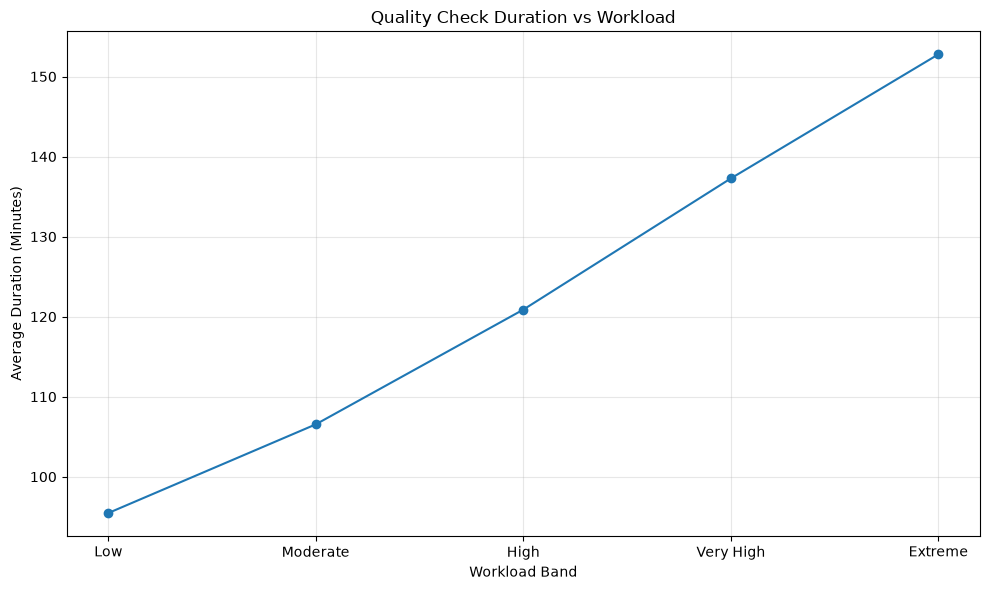

In [55]:
plt.figure(figsize=(10, 6))

plt.plot(
    bottleneck_workload["workload_band"],
    bottleneck_workload["avg_duration_minutes"],
    marker="o"
)

plt.title(
    "Quality Check Duration vs Workload"
)

plt.xlabel("Workload Band")
plt.ylabel(
    "Average Duration (Minutes)"
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()

In [56]:
quality_analysis = stages_analysis[
    stages_analysis["stage_name"]
    == "Quality Check"
].copy()

quality_correlation = quality_analysis[
    [
        "workload",
        "stage_duration_minutes"
    ]
].corr()

quality_correlation

,workload,stage_duration_minutes
workload,1.00,0.14
stage_duration_minutes,0.14,1.00


In [57]:
low_workload = quality_analysis[
    quality_analysis["workload_band"]
    == "Low"
]

extreme_workload = quality_analysis[
    quality_analysis["workload_band"]
    == "Extreme"
]

low_avg = (
    low_workload[
        "stage_duration_minutes"
    ].mean()
)

extreme_avg = (
    extreme_workload[
        "stage_duration_minutes"
    ].mean()
)

increase_pct = (
    (extreme_avg - low_avg)
    / low_avg
    * 100
)

print(
    f"Low workload average: "
    f"{low_avg:.2f} minutes"
)

print(
    f"Extreme workload average: "
    f"{extreme_avg:.2f} minutes"
)

print(
    f"Duration increase: "
    f"{increase_pct:.2f}%"
)

Low workload average: 95.45 minutes
Extreme workload average: 152.78 minutes
Duration increase: 60.05%


In [58]:
low_delay_rate = (
    low_workload["stage_status"]
    .eq("Delayed")
    .mean()
    * 100
)

extreme_delay_rate = (
    extreme_workload["stage_status"]
    .eq("Delayed")
    .mean()
    * 100
)

print(
    f"Low workload delay rate: "
    f"{low_delay_rate:.2f}%"
)

print(
    f"Extreme workload delay rate: "
    f"{extreme_delay_rate:.2f}%"
)

print(
    f"Delay-rate increase: "
    f"{extreme_delay_rate - low_delay_rate:.2f} percentage points"
)

Low workload delay rate: 51.61%
Extreme workload delay rate: 76.24%
Delay-rate increase: 24.64 percentage points


In [59]:
bottleneck_workload.to_csv(
    os.path.join(
        PROCESSED_DIR,
        "bottleneck_workload_analysis.csv"
    ),
    index=False
)

print(
    "Bottleneck workload analysis saved successfully."
)

Bottleneck workload analysis saved successfully.


In [60]:
quality_analysis = stages_analysis[
    stages_analysis["stage_name"] == "Quality Check"
].copy()

quality_correlation = quality_analysis[
    [
        "workload",
        "stage_duration_minutes"
    ]
].corr()

quality_correlation

,workload,stage_duration_minutes
workload,1.00,0.14
stage_duration_minutes,0.14,1.00


In [61]:
low_workload = quality_analysis[
    quality_analysis["workload_band"] == "Low"
]

extreme_workload = quality_analysis[
    quality_analysis["workload_band"] == "Extreme"
]

low_avg = low_workload[
    "stage_duration_minutes"
].mean()

extreme_avg = extreme_workload[
    "stage_duration_minutes"
].mean()

increase_pct = (
    (extreme_avg - low_avg)
    / low_avg
    * 100
)

low_delay_rate = (
    low_workload["stage_status"]
    .eq("Delayed")
    .mean()
    * 100
)

extreme_delay_rate = (
    extreme_workload["stage_status"]
    .eq("Delayed")
    .mean()
    * 100
)

print(f"Low workload average: {low_avg:.2f} minutes")
print(f"Extreme workload average: {extreme_avg:.2f} minutes")
print(f"Duration increase: {increase_pct:.2f}%")
print()
print(f"Low workload delay rate: {low_delay_rate:.2f}%")
print(f"Extreme workload delay rate: {extreme_delay_rate:.2f}%")
print(
    f"Delay-rate increase: "
    f"{extreme_delay_rate - low_delay_rate:.2f} percentage points"
)

Low workload average: 95.45 minutes
Extreme workload average: 152.78 minutes
Duration increase: 60.05%

Low workload delay rate: 51.61%
Extreme workload delay rate: 76.24%
Delay-rate increase: 24.64 percentage points


In [64]:
quality_rca = stages_analysis[
    stages_analysis["stage_name"] == "Quality Check"
].copy()

# Bring operational dimensions from fact_operations
quality_rca = quality_rca.merge(
    operations[
        [
            "operation_id",
            "employee_id",
            "location_id",
            "product_id",
            "quality_score",
            "cost",
            "quantity"
        ]
    ],
    on="operation_id",
    how="left"
)

print("Root cause dataset shape:", quality_rca.shape)
print("\nColumns:")
print(quality_rca.columns.tolist())

Root cause dataset shape: (150000, 18)

Columns:
['operation_id', 'stage_id', 'stage_name', 'stage_sequence', 'stage_start_time', 'stage_end_time', 'stage_duration_minutes', 'target_time_minutes', 'stage_variance_minutes', 'stage_status', 'workload_band', 'workload', 'employee_id', 'location_id', 'product_id', 'quality_score', 'cost', 'quantity']


In [65]:
experience_rca = (
    quality_rca
    .merge(
        employees[
            [
                "employee_id",
                "experience_level"
            ]
        ],
        on="employee_id",
        how="left"
    )
    .groupby("experience_level")
    .agg(
        operations=("operation_id", "nunique"),
        avg_duration_minutes=(
            "stage_duration_minutes",
            "mean"
        ),
        avg_variance_minutes=(
            "stage_variance_minutes",
            "mean"
        ),
        delay_rate_pct=(
            "stage_status",
            lambda x: (x == "Delayed").mean() * 100
        ),
        avg_workload=(
            "workload",
            "mean"
        )
    )
    .reset_index()
    .sort_values(
        "delay_rate_pct",
        ascending=False
    )
)

experience_rca

,experience_level,operations,avg_duration_minutes,avg_variance_minutes,delay_rate_pct,avg_workload
0,Junior,48966,131.61,56.61,69.07,8.63
1,Mid,70772,104.69,29.69,56.84,8.66
2,Senior,30262,89.79,14.79,47.76,8.67


In [67]:
locations.columns.tolist()

['location_id', 'region', 'facility_type', 'capacity']

In [68]:
location_rca = (
    quality_rca
    .merge(
        locations[
            [
                "location_id",
                "region",
                "facility_type",
                "capacity"
            ]
        ],
        on="location_id",
        how="left"
    )
    .groupby(["region", "facility_type"])
    .agg(
        operations=("operation_id", "nunique"),
        avg_duration_minutes=(
            "stage_duration_minutes",
            "mean"
        ),
        avg_variance_minutes=(
            "stage_variance_minutes",
            "mean"
        ),
        delay_rate_pct=(
            "stage_status",
            lambda x: (x == "Delayed").mean() * 100
        ),
        avg_workload=(
            "workload",
            "mean"
        ),
        capacity=("capacity", "mean")
    )
    .reset_index()
    .sort_values(
        "delay_rate_pct",
        ascending=False
    )
)

location_rca

,region,facility_type,operations,avg_duration_minutes,avg_variance_minutes,delay_rate_pct,avg_workload,capacity
0,Central,Distribution Center,12123,112.70,37.70,59.57,8.66,555.27
12,West,Processing Hub,5907,110.54,35.54,59.56,8.59,521.00
1,Central,Fulfillment Center,5884,111.51,36.51,59.45,8.72,500.00
9,South,Processing Hub,6048,110.82,35.82,59.42,8.62,404.00
11,West,Fulfillment Center,6000,110.34,35.34,59.33,8.61,828.00
5,North,Distribution Center,5902,109.46,34.46,59.25,8.63,608.00
4,East,Processing Hub,17965,110.10,35.10,59.19,8.71,703.54
3,East,Fulfillment Center,11946,110.33,35.33,59.12,8.62,728.95
6,North,Fulfillment Center,5933,110.80,35.80,59.11,8.66,359.00
10,West,Distribution Center,24012,110.41,35.41,58.93,8.67,534.77


In [70]:
products.columns.tolist()

['product_id', 'category', 'subcategory']

In [71]:
product_rca = (
    quality_rca
    .merge(
        products[
            [
                "product_id",
                "category",
                "subcategory"
            ]
        ],
        on="product_id",
        how="left"
    )
    .groupby(["category", "subcategory"])
    .agg(
        operations=("operation_id", "nunique"),
        avg_duration_minutes=(
            "stage_duration_minutes",
            "mean"
        ),
        avg_variance_minutes=(
            "stage_variance_minutes",
            "mean"
        ),
        delay_rate_pct=(
            "stage_status",
            lambda x: (x == "Delayed").mean() * 100
        ),
        avg_workload=(
            "workload",
            "mean"
        )
    )
    .reset_index()
    .sort_values(
        "delay_rate_pct",
        ascending=False
    )
)

product_rca

,category,subcategory,operations,avg_duration_minutes,avg_variance_minutes,delay_rate_pct,avg_workload
13,Industrial,Machinery,8830,111.40,36.40,59.58,8.67
3,Electronics,Accessories,12270,111.21,36.21,59.38,8.68
10,Home,Decor,9185,112.23,37.23,59.36,8.61
0,Consumer Goods,Food,9486,111.36,36.36,59.34,8.66
4,Electronics,Components,6931,110.32,35.32,59.18,8.64
12,Industrial,Equipment,9503,109.81,34.81,59.17,8.62
6,Healthcare,Diagnostics,9119,110.30,35.30,59.15,8.64
5,Electronics,Devices,10774,110.08,35.08,59.04,8.62
11,Home,Furniture,7244,110.32,35.32,58.93,8.72
8,Healthcare,Supplies,7847,110.09,35.09,58.84,8.71


In [72]:
experience_workload_rca = (
    quality_rca
    .merge(
        employees[
            [
                "employee_id",
                "experience_level"
            ]
        ],
        on="employee_id",
        how="left"
    )
    .groupby(["experience_level", "workload_band"])
    .agg(
        operations=("operation_id", "nunique"),
        avg_duration_minutes=(
            "stage_duration_minutes",
            "mean"
        ),
        avg_variance_minutes=(
            "stage_variance_minutes",
            "mean"
        ),
        delay_rate_pct=(
            "stage_status",
            lambda x: (x == "Delayed").mean() * 100
        )
    )
    .reset_index()
    .sort_values(
        ["experience_level", "delay_rate_pct"],
        ascending=[True, False]
    )
)

experience_workload_rca

C:\Users\rajpa\AppData\Local\Temp\ipykernel_12352\1645415093.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["experience_level", "workload_band"])


,experience_level,workload_band,operations,avg_duration_minutes,avg_variance_minutes,delay_rate_pct
4,Junior,Extreme,340,183.12,108.12,83.82
3,Junior,Very High,2756,164.91,89.91,78.99
2,Junior,High,12536,144.17,69.17,73.26
1,Junior,Moderate,25199,126.97,51.97,67.64
0,Junior,Low,8135,113.17,38.17,63.04
9,Mid,Extreme,514,146.34,71.34,77.43
8,Mid,Very High,3783,128.93,53.93,68.20
7,Mid,High,18502,114.97,39.97,62.46
6,Mid,Moderate,36576,100.73,25.73,55.08
5,Mid,Low,11397,90.77,15.77,48.63


In [73]:
rca_impact = (
    experience_workload_rca
    .groupby("experience_level")
    .agg(
        lowest_delay_rate_pct=("delay_rate_pct", "min"),
        highest_delay_rate_pct=("delay_rate_pct", "max"),
        avg_delay_rate_pct=("delay_rate_pct", "mean")
    )
    .reset_index()
)

rca_impact["delay_rate_range_pct"] = (
    rca_impact["highest_delay_rate_pct"]
    - rca_impact["lowest_delay_rate_pct"]
)

rca_impact.sort_values(
    "delay_rate_range_pct",
    ascending=False
)

,experience_level,lowest_delay_rate_pct,highest_delay_rate_pct,avg_delay_rate_pct,delay_rate_range_pct
1,Mid,48.63,77.43,62.36,28.81
2,Senior,39.52,62.50,52.47,22.98
0,Junior,63.04,83.82,73.35,20.79


In [74]:
experience_rca.to_csv(
    os.path.join(PROCESSED_DIR, "quality_experience_rca.csv"),
    index=False
)

location_rca.to_csv(
    os.path.join(PROCESSED_DIR, "quality_location_rca.csv"),
    index=False
)

product_rca.to_csv(
    os.path.join(PROCESSED_DIR, "quality_product_rca.csv"),
    index=False
)

experience_workload_rca.to_csv(
    os.path.join(PROCESSED_DIR, "quality_experience_workload_rca.csv"),
    index=False
)

rca_impact.to_csv(
    os.path.join(PROCESSED_DIR, "quality_rca_impact.csv"),
    index=False
)

print("RCA datasets saved successfully.")

RCA datasets saved successfully.


In [75]:
rca_correlation = quality_rca[
    [
        "stage_duration_minutes",
        "stage_variance_minutes",
        "workload",
        "quality_score",
        "cost",
        "quantity"
    ]
].corr()

rca_correlation

,stage_duration_minutes,stage_variance_minutes,workload,quality_score,cost,quantity
stage_duration_minutes,1.00,1.00,0.14,-0.80,0.88,0.15
stage_variance_minutes,1.00,1.00,0.14,-0.80,0.88,0.15
workload,0.14,0.14,1.00,-0.10,0.24,0.92
quality_score,-0.80,-0.80,-0.10,1.00,-0.80,-0.11
cost,0.88,0.88,0.24,-0.80,1.00,0.26
quantity,0.15,0.15,0.92,-0.11,0.26,1.00


In [76]:
rca_correlation.to_csv(
    os.path.join(PROCESSED_DIR, "quality_rca_correlation.csv")
)

print("RCA correlation analysis saved successfully.")

RCA correlation analysis saved successfully.


In [77]:
rca_priority = pd.DataFrame({
    "factor": [
        "Employee Experience",
        "Workload",
        "Experience × Workload",
        "Location / Facility",
        "Product Category"
    ],
    "evidence": [
        "Delay rate: 47.76%–69.07%",
        "Delay rate: 51.61%–76.24% across workload bands",
        "Junior + Extreme workload: 83.82% delay",
        "Delay rate: 57.88%–59.57%",
        "Delay rate: 58.57%–59.58%"
    ],
    "priority": [
        "High",
        "High",
        "Very High",
        "Low",
        "Low"
    ]
})

rca_priority

,factor,evidence,priority
0,Employee Experience,Delay rate: 47.76%–69.07%,High
1,Workload,Delay rate: 51.61%–76.24% across workload bands,High
2,Experience × Workload,Junior + Extreme workload: 83.82% delay,Very High
3,Location / Facility,Delay rate: 57.88%–59.57%,Low
4,Product Category,Delay rate: 58.57%–59.58%,Low


In [78]:
rca_priority.to_csv(
    os.path.join(PROCESSED_DIR, "quality_rca_priority.csv"),
    index=False
)

print("RCA priority ranking saved successfully.")

RCA priority ranking saved successfully.


In [79]:
rca_correlation.to_csv(
    os.path.join(PROCESSED_DIR, "quality_rca_correlation.csv")
)

print("RCA correlation matrix saved successfully.")

RCA correlation matrix saved successfully.


In [80]:
management_rca = pd.DataFrame({
    "issue": [
        "Quality Check Bottleneck",
        "Employee Experience Gap",
        "Workload Pressure",
        "Experience × Workload"
    ],
    "finding": [
        "Quality Check averages 110.47 min vs 75 min target",
        "Junior employees have the highest delay rate at 69.07%",
        "Extreme workload reaches 76.24% delay rate",
        "Junior + Extreme workload reaches 83.82% delay rate"
    ],
    "business_impact": [
        "Primary operational bottleneck",
        "Higher delays and longer processing time",
        "Performance deteriorates as workload increases",
        "Highest-risk operating segment"
    ],
    "recommended_action": [
        "Optimize Quality Check capacity and workflow",
        "Increase training/support for junior employees",
        "Balance workload across resources",
        "Prioritize experienced resources for peak workload"
    ]
})

management_rca

,issue,finding,business_impact,recommended_action
0,Quality Check Bottleneck,Quality Check averages 110.47 min vs 75 min ta...,Primary operational bottleneck,Optimize Quality Check capacity and workflow
1,Employee Experience Gap,Junior employees have the highest delay rate a...,Higher delays and longer processing time,Increase training/support for junior employees
2,Workload Pressure,Extreme workload reaches 76.24% delay rate,Performance deteriorates as workload increases,Balance workload across resources
3,Experience × Workload,Junior + Extreme workload reaches 83.82% delay...,Highest-risk operating segment,Prioritize experienced resources for peak work...


In [81]:
management_rca.to_csv(
    os.path.join(PROCESSED_DIR, "management_rca_summary.csv"),
    index=False
)

print("Management RCA summary saved successfully.")

Management RCA summary saved successfully.


In [83]:
stage_performance.columns.tolist()

['stage_name',
 'operations',
 'avg_duration_minutes',
 'median_duration_minutes',
 'target_time_minutes',
 'avg_variance_minutes',
 'delayed_operations',
 'delay_rate_pct',
 'variance_pct']

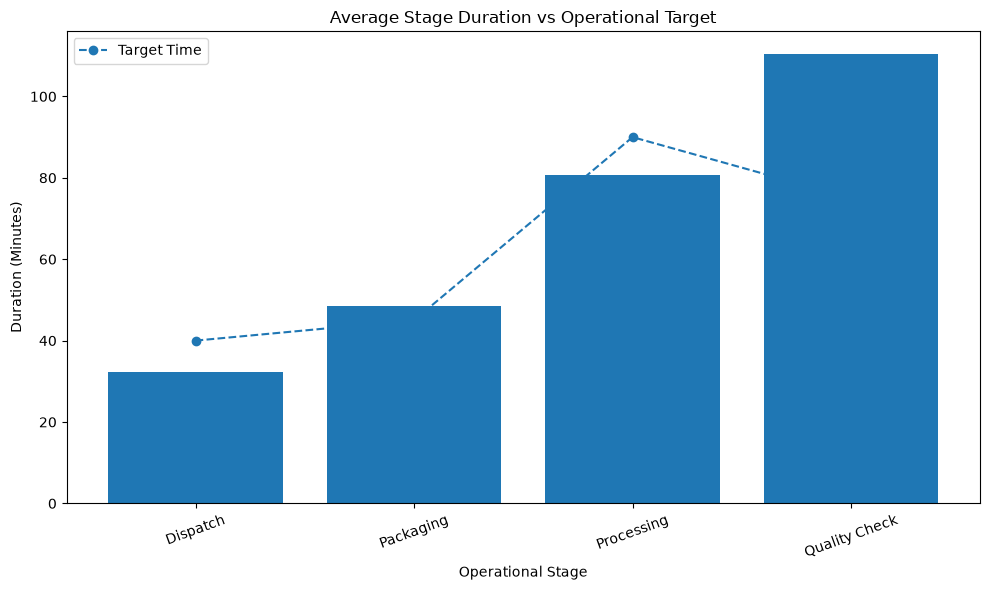

In [84]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.bar(
    stage_performance["stage_name"],
    stage_performance["avg_duration_minutes"]
)

plt.plot(
    stage_performance["stage_name"],
    stage_performance["target_time_minutes"],
    marker="o",
    linestyle="--",
    label="Target Time"
)

plt.title("Average Stage Duration vs Operational Target")
plt.xlabel("Operational Stage")
plt.ylabel("Duration (Minutes)")
plt.xticks(rotation=20)
plt.legend()
plt.tight_layout()

plt.show()

In [85]:
chart_path = os.path.join(
    PROJECT_DIR,
    "documents",
    "quality_check_bottleneck.png"
)

plt.savefig(
    chart_path,
    dpi=300,
    bbox_inches="tight"
)

print(f"Chart saved to: {chart_path}")

Chart saved to: c:\Users\rajpa\Downloads\OpsPulse Operational Intelligence\documents\quality_check_bottleneck.png


<Figure size 640x480 with 0 Axes>

In [86]:
pd.read_csv(
    os.path.join(RAW_DIR, "dim_employee.csv")
).head()

,employee_id,department,team,experience_level
0,EMP_0001,Quality,Team D,Mid
1,EMP_0002,Processing,Team A,Mid
2,EMP_0003,Processing,Team A,Junior
3,EMP_0004,Processing,Team E,Senior
4,EMP_0005,Processing,Team B,Mid
